# Crank Nicolson Method for Heat Equation

Solve:
\begin{align*}
  u_t  &= \alpha^2 u_{xx} \\
u(x,0) &= g(x)\\
u(0,t) &= A \\
u(L,t) &= B \\
(t,x) &\in \mathbb{R}^{+} \times (0,L)
\end{align*}

For a discretization of the domain via $x_i, t_j$, then the solution $u$ can be identified with the matrix $U$ under the correspondence rule:

$$ U_i^j = u(x_i, t_j) $$

Thus, the algorithm to follow is:

$$ - \lambda U_{i+1}^{j+1} + (1+2\lambda) U_i^{j+1} - \lambda U_{i-1}^{j+1} = \lambda U_{i+1}^j + (1-2\lambda) U_i^j + \lambda U_{i-1}^j, $$

Where $i = 1, \cdots, n-1, \, j = 1, \cdots, m-1$ and $\lambda = \dfrac{\alpha^2 k}{2 h^2}$

Notice that from the boundary conditions one has for any $i,j$:
\begin{align*}
U_i^0 &= u(x_i, t_0) = u(x_i, 0) = g(x_i)\\
U_0^j &= A \\
U_{n}^j &= B\\
\end{align*}

## Example
For the sake of simplicty, consider:
$$
\begin{align*}
u_t &= u_{xx},\\
u(x,0) &= \sin (\pi x)\\
u (0,t) &= 0\\
u (1,t) &= 0 \\
(t,x) &\in (0, 1)^2
\end{align*}
$$

In [1]:
import numpy as np

def g(x) -> np.float64:
    return np.sin(np.pi * x)
 
L = T = ALPHA = np.float64(1)
A = B = np.float64(0)

N = 10          # space discretization
M = 500         # time discretization
H = L/N
K = T/M
LAMBDA = (ALPHA**2 * K) / (2 * H**2)

### Tridiagonal system
In Linear Algebra terms, the system to solve is:

$$

\begin{pmatrix}
1+2\lambda & -\lambda & 0 & \cdots & 0 \\
-\lambda & 1+2\lambda & -\lambda & \cdots & 0 \\
0 & -\lambda & 1+2\lambda & \cdots & 0 \\
\vdots & & & \ddots & \vdots \\
0 & 0 & 0 & \cdots & 1+2\lambda
\end{pmatrix} 
\cdot 
\begin{pmatrix} 
U_1^{j+1} \\
\vdots \\
U_{n-1}^{j+1} \\
\end{pmatrix}
= 
\begin{pmatrix}
1-2\lambda & \lambda & 0 & \cdots & 0 \\
\lambda & 1-2\lambda & \lambda & \cdots & 0 \\
0 & \lambda & 1-2\lambda & \cdots & 0 \\
\vdots & & & \ddots & \vdots \\
0 & 0 & 0 & \cdots & 1-2\lambda
\end{pmatrix} 
\cdot 
\begin{pmatrix} 
U_1^{j} \\
\vdots \\
U_{n-1}^{j} \\
\end{pmatrix}

$$

With $U^0 = g(x)$, $U_0^j = A$, and $U_n^j = B$. 

In [2]:
from scipy.linalg import solve_banded
from utils.linalg import tridiag, gen_ab

def solver(
        xx: np.ndarray, 
        m: int,
        param: float, 
) -> np.ndarray:
    
    n, = xx.shape

    # n-2 since we are not including boundary conditions
    ab = gen_ab(n - 2, param)
    m_right = tridiag(n - 2, 1 - 2*param, param)
    res = np.empty([n - 2, m])

    res[:, 0] = g(xx)[1: -1]
    for j in range(m - 1):
        right = m_right.dot(res[:, j])
        res[:, j + 1] = solve_banded((1, 1), ab, right)
    
    # merge with boundary conditions
    boundary_a = np.full(m, A)
    boundary_b = np.full(m, B)
    result = np.vstack((boundary_a, res, boundary_b))
    return result


xx = np.linspace(0, L, N)
tt = np.linspace(0, T, M)
mat = solver(xx, M, LAMBDA)

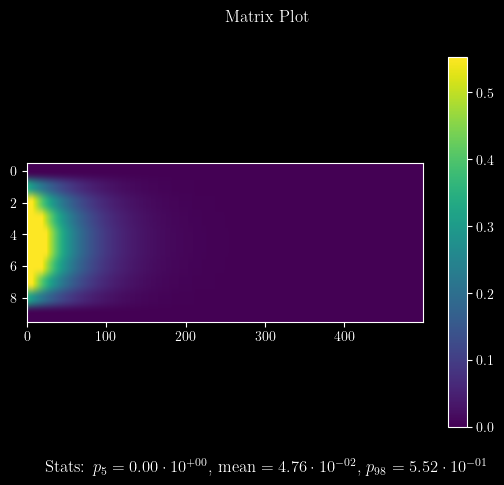

In [3]:
import matplotlib.pyplot as plt

from utils.visualization import matrix_plot, init

init()
fig, ax = matrix_plot(mat, [5, 98])
ax.set_aspect(20)
plt.show()

### TODO: Implement super-mega solver
The system from the previous section can be still simplified:
$$
\begin{pmatrix}
-\Lambda_2 & \Lambda_1 & 0 & \cdots & 0 \\
0 & -\Lambda_2 & \Lambda_1 & \cdots & 0 \\
0 & 0 & -\Lambda_2 & \cdots & 0 \\
\vdots & & & \ddots & \vdots \\
0 & 0 & 0 & \cdots & -\Lambda_2
\end{pmatrix} \cdot U'
= 0
$$
Where $U' = ({U'}^j)$ and the system is derived from $\Lambda_1 {U'}^{j+1}= \Lambda_2 {U'}^j$ considering ${U'}^j = (U_i^j)_{i=1, \cdots, m-1}$ (concatenated in a single 1D vector). This improves performance since no recursive iteration is needed in contrast to `solver`.

# Results

The exact solution of the differential equation is $u(x,t) = \sin(\pi x) \exp(-\pi^2 t)$. Let's see how close the discretization is from the actual solution.

In [4]:
from utils.calculus import discretize

def solution(x, t) -> np.float64:
    sin = np.sin(np.pi * x)
    exp = np.exp(- np.pi ** 2 * t)
    return sin * exp

arr = discretize(solution, xx, tt)

The plot is arguably the same compared to `mat`

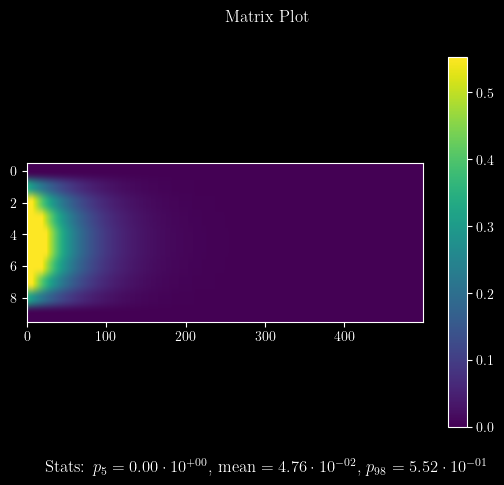

In [5]:
fig, ax = matrix_plot(mat, [5, 98])
ax.set_aspect(20)
plt.show()

Comparing their differences

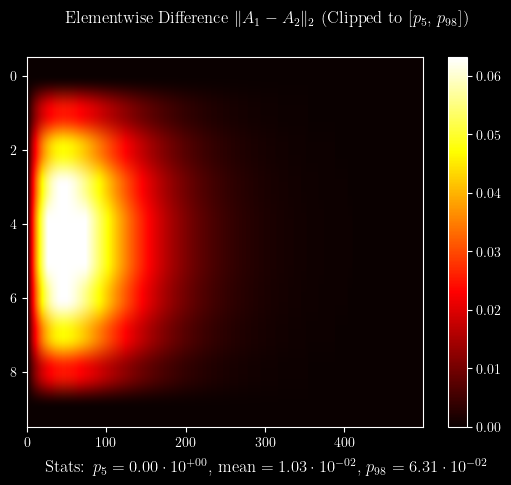

In [6]:
from utils.visualization import matrix_diff_plot

fig, ax = matrix_diff_plot(arr, mat, [5, 98])
plt.show()

#### Plotting for some parameters

In [7]:
from typing import Callable

def solparam(
        tt: np.ndarray, 
        samples: int = 6,
) -> Callable[[float], float]:
    
    n, = tt.shape
    ttsampled = tt[ : : n // samples]
    def solrn(x: float) -> float:
        return solution(x, ttsampled)
    return solrn

Let's also generate the labels programmatically

In [8]:
from utils.visualization import latex_float

def gen_label(floats: list[float]) -> str:
    label = f"$u(x,t) = \\sin(\\pi x) \\exp(-\\pi^2 t)$"
    labels = [label.replace('t', latex_float(f)) for f in floats]
    return labels

Sampling our arrays (instead you want to plot 500 lines / points).

In [9]:
samples = 3
funcs = np.vectorize(
    solparam(tt, samples), 
    signature='()->(n)'
)

sampled_mat = mat[:, : : M // samples]
labels = gen_label(tt[: : M // samples])

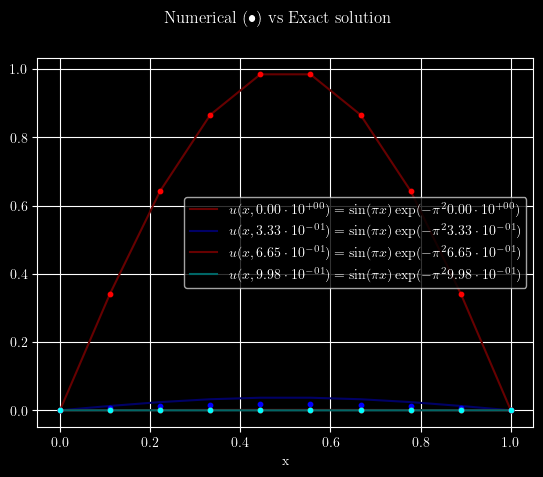

In [16]:
from utils.visualization import compare_numerical

fig, ax = compare_numerical(
    funcs, xx, xx, sampled_mat,
    xlabel="x",
    colors=['red', 'blue', 'red', 'cyan'],
    labels=labels,
    colorfactor=-0.6
)

plt.show()